# Oppgave uke 43

* Gjør ferdig oppgavene fra uke 42 først :)

## Arbeidsledighet og fraflytting

Vi har i timen sett på et befolkningsdatasett og på et sysselsettingsdatasett.
Et spørsmål vi kanskje har lyst til å stille oss er om det er en sammenheng mellom arbeidsledigheten i kommunene
og fraflyttingen.


* Du kan bruke datasettet fra uke 43 for befolkning og endringer
* Du må sannsynligvis inn på SSB og finne data om arbeidsledighet/sysselsetting etter kommune

* I grove trekk må du lage deg et dataframe i pandas som inneholder de relevante variablene fra de to datasettene
* For å se etter sammenhenger mellom sysselsetting og fraflytting, kan vi feks:
    - Lage forskjellige plot og se på sammenhengene grafisk
    - Sjekke korrelasjon mellom arbeidsledighet, fraflytting, endring i fraflytting eller netto vekst

potensielt aktuelle tabeller:

* 07984 - Sysselsatte personer etter bosted (kvartalsvis fra 2008)
* 12539 mer eller mindre samme
* 07459 - aldersfordeling

### Ekstra utfordringer
Arbeidsledighet på kommunenivå måtte «prikkes» etter endring i regelverket i 2021.
Vi har tilgjengelig data om sysselsatte på kommunenivå per 4. kvartal

/tmp/ipykernel_6924/2145826992.py:68: RuntimeWarning: invalid value encountered in long_scalars
  df2.loc[(k,y), "endring utflyttinger"] = 1-df2.loc[(k,y), "Utflyttinger"]/df2.loc[(k,y-1), "Utflyttinger"]
/tmp/ipykernel_6924/2145826992.py:68: RuntimeWarning: divide by zero encountered in long_scalars
  df2.loc[(k,y), "endring utflyttinger"] = 1-df2.loc[(k,y), "Utflyttinger"]/df2.loc[(k,y-1), "Utflyttinger"]


,endring sysselsatte,Sysselsatte(per 100),endring utflyttinger,Utflyttinger,Folketilvekst
endring sysselsatte,1.000000,-0.155696,-0.232745,-0.006769,-0.020917
Sysselsatte(per 100),-0.155696,1.000000,0.029543,0.139456,0.186699
endring utflyttinger,-0.232745,0.029543,1.000000,0.008386,0.014159
Utflyttinger,-0.006769,0.139456,0.008386,1.000000,0.898864
Folketilvekst,-0.020917,0.186699,0.014159,0.898864,1.000000


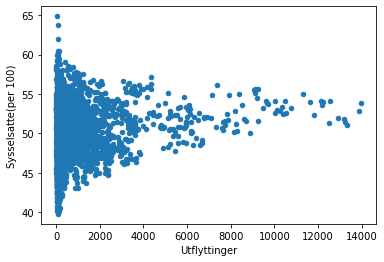

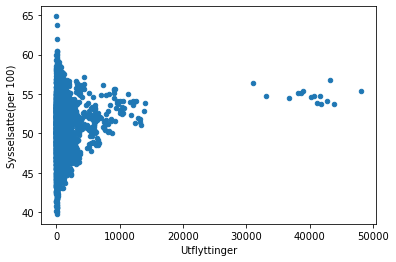

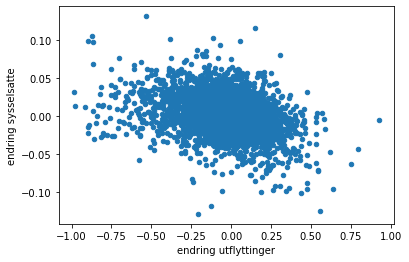

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SSBENC = "ISO-8859-1" #Tegnkoding 

#Les data om sysselsetting
sysselsatte_df = pd.read_csv("07984_20231106-110659.csv",
                            header = 1, encoding=SSBENC, sep = ";")

sysselsatte_df.drop("statistikkvariabel", axis=1, inplace=True) #Fjern kolonne "statistikkvariabel"

# Les data om populasjon
pop_df = pd.read_csv("06913_20231018-082252.csv",
                    header=1, encoding=SSBENC, sep=";")

# Funksjon som tar en tekststreng navn og bytter ut '.' med '_'
def fiks_kommunenavn(navn):
    return navn.replace('.','_')

# Kall funksjonen fiks_kommunenavn på alle elementer i region-kolonnen
# Vi kunne også brukt pd.replace(---)
sysselsatte_df["region"] = sysselsatte_df["region"].map(fiks_kommunenavn)

# Funksjonen melt flater ut tabellen - årskolonnene blir egne rader
sysselsatte_df = sysselsatte_df.melt(id_vars=["region"], value_vars=sysselsatte_df.drop("region", axis=1).columns)

# Angi datatype til "variable" kolonnen
sysselsatte_df = sysselsatte_df.astype({"variable": "Int64"})

#Gjør om til multiindeks Kommune, år
sysselsatte_df.set_index(["region", "variable"], inplace=True)
#Sorter indeksen
sysselsatte_df.sort_index(inplace=True)
# Skift navn fra value -> Sysselsatte
sysselsatte_df.rename(columns={"value": "Sysselsatte"}, inplace=True)
#Sett navn på indeksen 
sysselsatte_df.index.names = ["region", "år"]

#Populasjonsdataframe:
#Gjør om til multiindeks kommune, år
pop_df = pop_df.set_index(["region", "år"])
#Fjern levendefødte og døde kolonnene
pop_df = pop_df.drop(["Levendefødte", "Døde",], axis=1)
#Bytt ut ".." (tom data) med np.NaN
pop_df.replace('..', np.NaN, inplace=True)
# Skift datatype til Int64
pop_df = pop_df.astype("Int64")

#Sett sammen populasjon og sysselsettingsdataset
df = pop_df.join(sysselsatte_df)
#Velg ut år 2008 ->
df2 = df.query("år >= 2008 and år < 2023").copy()
#Lag ny kolonne med prosentandel sysselsetting
df2["Sysselsatte(per 100)"] = df2["Sysselsatte"]*100/df2["Befolkning 1. januar"]
df2.sort_index(inplace=True)

#Scatterplot av utflyttinger mot sysselsatte per 100:
df2.query("Utflyttinger < 20000").plot.scatter(x="Utflyttinger", y="Sysselsatte(per 100)")
df2.plot.scatter(x="Utflyttinger", y="Sysselsatte(per 100)")


kommuner = {k for k,v in df2.index} # Vi lager et sett med alle kommunene

#For alle kommuner skal vi legge til to kolonner: Endring i utflyttinger og sysselsatte
for k in kommuner:
    for y in range(2009,2023): #Gyldige år å beregne endringer er 2009 til 2022
        df2.loc[(k,y), "endring utflyttinger"] = 1-df2.loc[(k,y), "Utflyttinger"]/df2.loc[(k,y-1), "Utflyttinger"]
        df2.loc[(k,y), "endring sysselsatte"] = 1-df2.loc[(k,y), "Sysselsatte(per 100)"]/df2.loc[(k,y-1), "Sysselsatte(per 100)"]
    
df2.query("abs(`endring utflyttinger`) < 1").plot.scatter(x="endring utflyttinger", y="endring sysselsatte")
df2[["endring sysselsatte", "Sysselsatte(per 100)", "endring utflyttinger", "Utflyttinger", "Folketilvekst"]].corr()

/usr/lib/python3/dist-packages/numpy/lib/histograms.py:837: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/lib/python3/dist-packages/numpy/lib/histograms.py:838: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


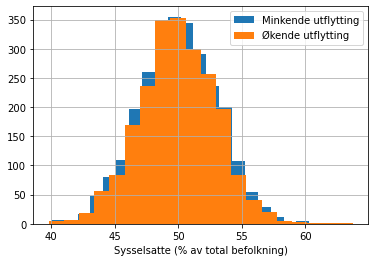

In [28]:
#df2["Sysselsatte(per 100)"].hist(bins=20)
df2.query("`endring utflyttinger`<0.0")["Sysselsatte(per 100)"].hist(bins=20, label="Minkende utflytting")
df2.query("`endring utflyttinger`>0.0")["Sysselsatte(per 100)"].hist(bins=20, label="Økende utflytting")
plt.legend()
plt.xlabel("Sysselsatte (% av total befolkning)")
plt.show()

## Kjapp diskusjon

### Histogram

I histogrammet har viser har vi tatt alle kommuner over alle år og delt de i 2 set: Et hvor utfyttingene økte fra året før, og et hvor ut utflytningen sank. Langs x-aksen har vi sysselsettingen i %. Dersom arbeidsmarkedet har sterk påvirkning på utflytningen hadde vi kanskje forventet at histogrammene var "forskøvet" - I år med minkende utflytting skulle sysselsettingen være høyere og i år med økende utflytting skulle sysselsettingen i snitt være lavere.

Dette er vanskelig å se om er tilfellet - histogrammene ser ut til å ha toppen på samme sted ~50%

### Prikkeplott

I prikkeplottet har vi lagt inn alle kommuner for alle år, punktene har endring i utflyttinger (%) som x-koordinat
og endringer i sysselsatte (%) som y-koordinat. Dersom det ikke er noen korrelasjon mellom de to - forventer vi at prikkene faller inn i en sirkel eller  en ellipse med aksene parallelle med x/y-aksene. Prikkeplottet ser ut til å falle i en ellipse med aksene "vridd" med klokken - den ser ut til å peke litt på skrå ned mot høyre. Dette tyder på en lineær korrelasjon mellom fraflytting og arbeidsmarkedet 

### Korrelasjon (pearson)

Dersom vi regner ut korrelasjonen mellom et utvalg av variablene våre, kan vi se at det er en negativ korrelasjon på ~-0.23 mellom endring i sysselsetting og endring i utflytting. Dersom vi ser på tilfeldige kommuner på et tilfeldig år etter 2008, kan vi derfor si at dersom utflyttingen fra kommunen synker, har andelen sysselsatte en tendens til å stige

### Svakheter 

Det er masse potensielle problem med en enkel analyse på en store og sammensatte sosioøkonomiske variabler som arbeidsledighet, sysselsetting og populasjon. Feks:
* I vår analyse tar vi ikke hensyn til at om mange leter etter arbeid, gir opp, og flytter, så vil prosentvis sysselsetting øke.
* Kommunesammenslåinger kan lage masse rot
